In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("sample_data/student_performance_dataset.csv")
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [ ]:
print("Shape:", df.shape)

df.info()

Shape: (3000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  

In [ ]:
df.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
city_type,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,60
doomscrolling_before_sleep,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
city_type,object
study_hours_per_day,float64
deep_work_sessions,int64
assignment_completion_rate,int64
attendance_percentage,int64
social_media_hours,float64
doomscrolling_before_sleep,int64


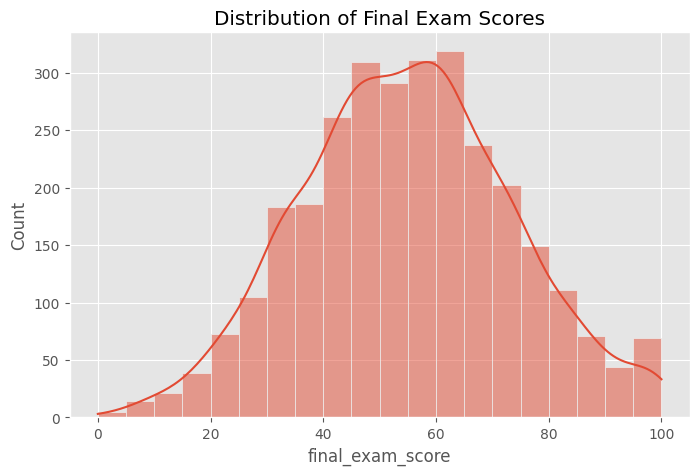

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["final_exam_score"], bins=20, kde=True)

plt.title("Distribution of Final Exam Scores")
plt.show()

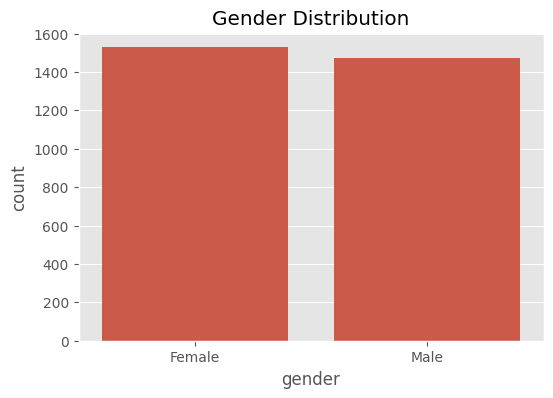

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

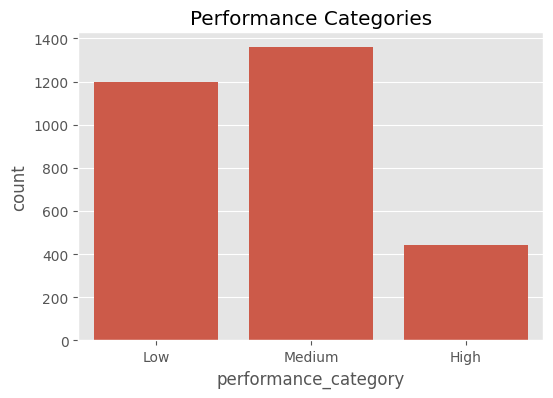

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="performance_category")
plt.title("Performance Categories")
plt.show

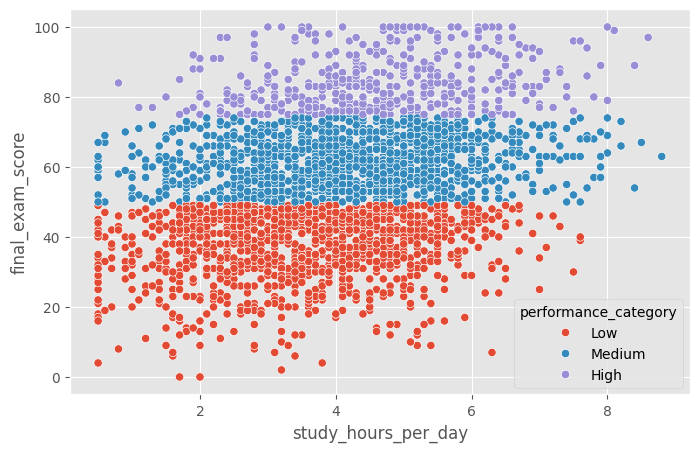

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="study_hours_per_day", y="final_exam_score", hue="performance_category")
plt.show()

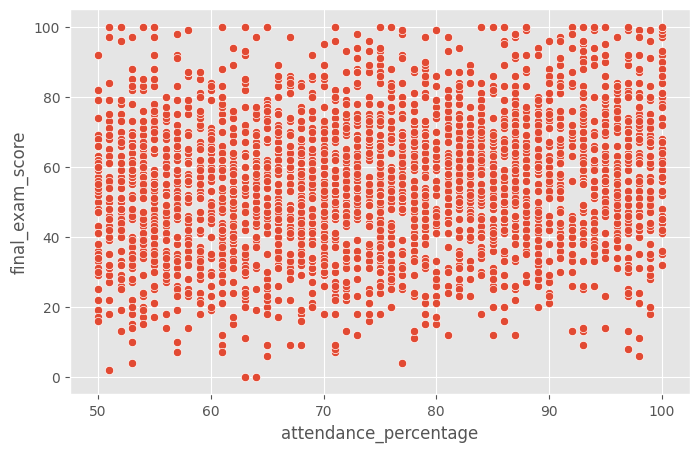

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="attendance_percentage", y="final_exam_score")
plt.show()

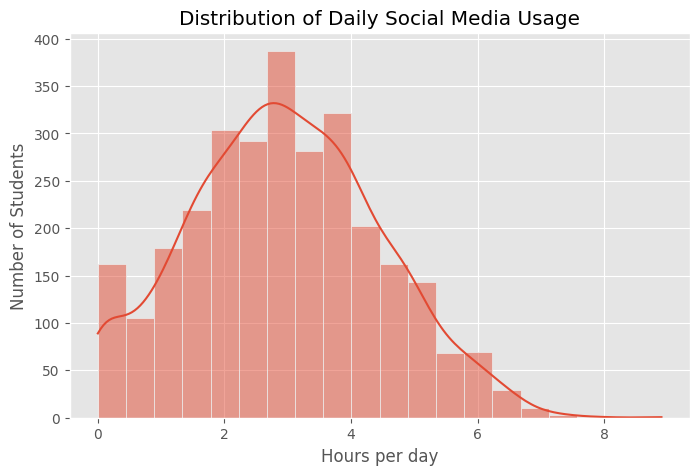

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["social_media_hours"],bins=20, kde=True)
plt.title("Distribution of Daily Social Media Usage")
plt.xlabel("Hours per day")
plt.ylabel("Number of Students")
plt.show()

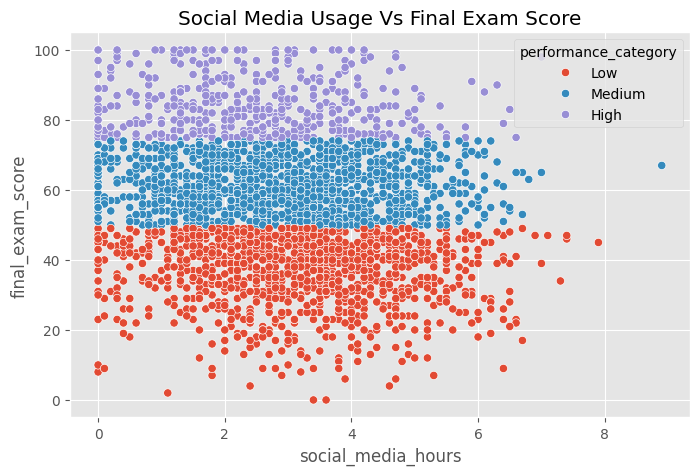

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="social_media_hours", y="final_exam_score", hue="performance_category")
plt.title("Social Media Usage Vs Final Exam Score")
plt.show()

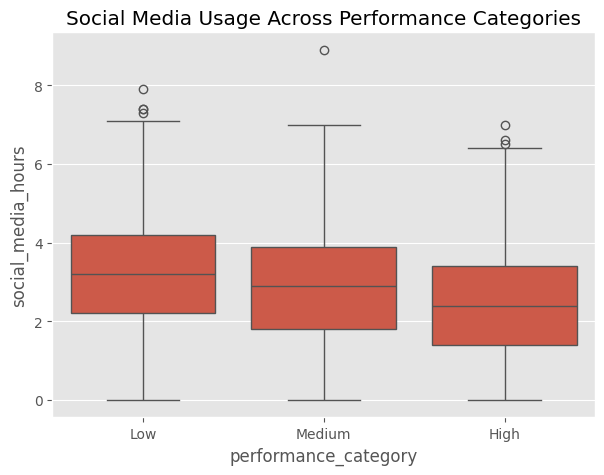

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="performance_category", y="social_media_hours")
plt.title("Social Media Usage Across Performance Categories")
plt.show()

doomscrolling_before_sleep
No     1521
Yes    1479
Name: count, dtype: int64


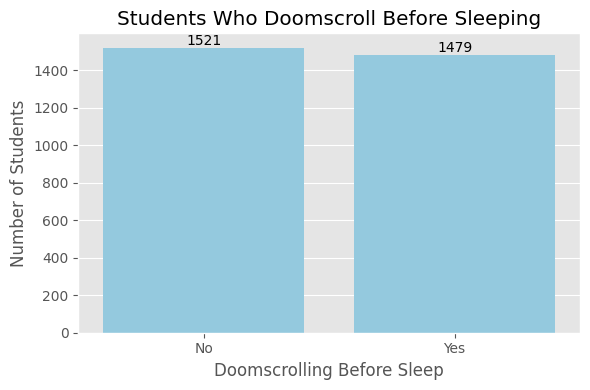

In [ ]:
df = pd.read_csv("sample_data/student_performance_dataset.csv")

df["doomscrolling_before_sleep"] = df["doomscrolling_before_sleep"].replace({
    0: "No",
    1: "Yes"
})

print(df["doomscrolling_before_sleep"].value_counts(dropna=False))

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="doomscrolling_before_sleep",
    order=["No", "Yes"],
    color="skyblue"
)

plt.title("Students Who Doomscroll Before Sleeping")
plt.xlabel("Doomscrolling Before Sleep")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
label=LabelEncoder()
for col in df.select_dtypes(include="object", ).columns:
    df[col]=label.fit_transform(df[col])

In [ ]:
x=df.drop("performance_category", axis=1)
y=df["performance_category"]

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
model=RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
predictions=model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", accuracy)

Accuracy:  0.995


In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        92
           1       1.00      1.00      1.00       230
           2       0.99      1.00      0.99       278

    accuracy                           0.99       600
   macro avg       1.00      0.99      0.99       600
weighted avg       1.00      0.99      0.99       600



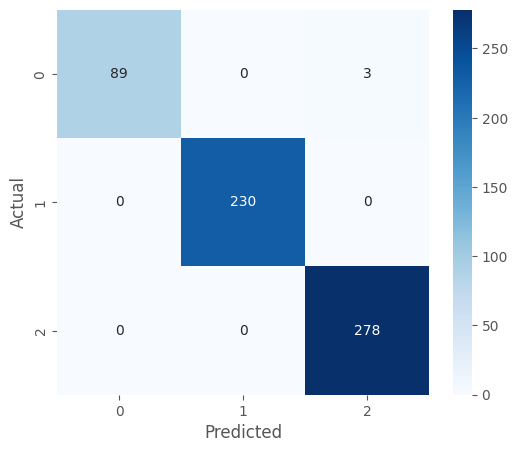

In [ ]:
cm =confusion_matrix(y_test,predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
30,final_exam_score,0.642097
4,study_hours_per_day,0.030359
29,consistency_score,0.024399
16,procrastination_index,0.023113
15,focus_score,0.021535
8,social_media_hours,0.019494
7,attendance_percentage,0.017617
27,revision_efficiency,0.016510
28,burnout_risk,0.014140
14,motivation_level,0.014113


In [ ]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", accuracy)

Accuracy:  0.995


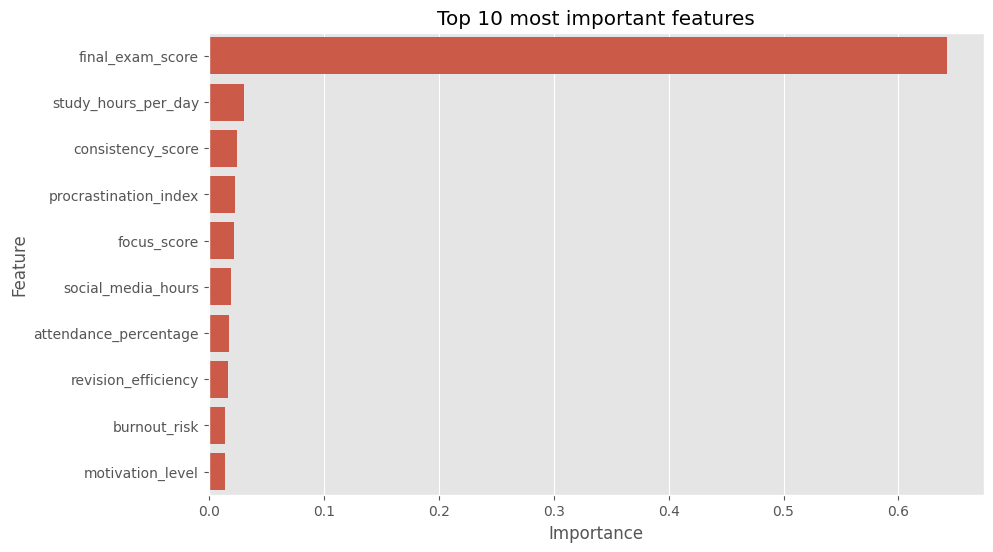

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10),x="Importance", y="Feature")
plt.title("Top 10 most important features")
plt.show()

<Axes: xlabel='gender', ylabel='performance_category'>

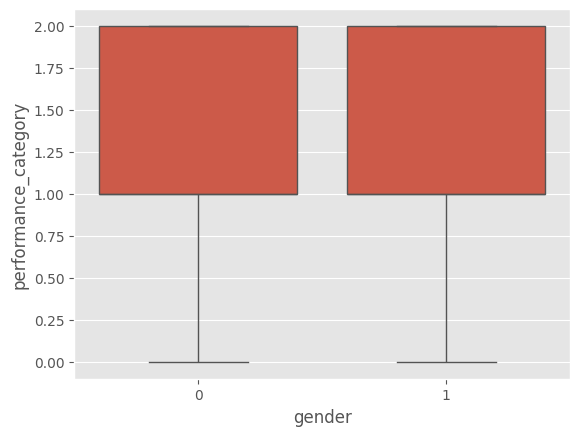

In [ ]:
sns.boxplot(x="gender", y="performance_category", data=df)

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

In [ ]:
df['ai_dependency']=(
    df['ai_tool_usage_hours']/(df['study_hours_per_day'] + 1)
)

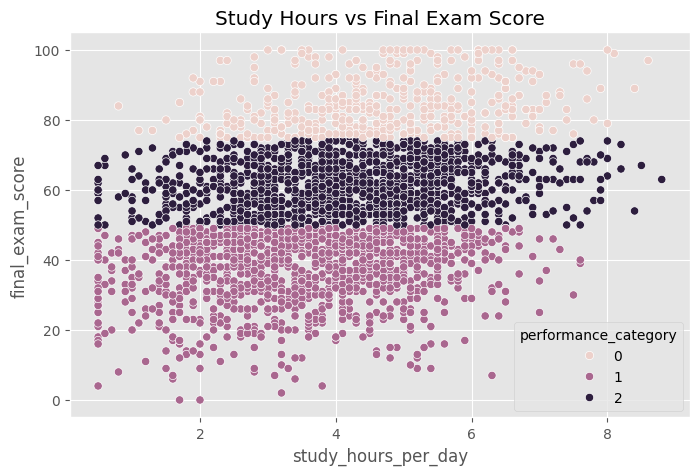

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="study_hours_per_day",
    y="final_exam_score",
    hue="performance_category",
    data=df
)

plt.title("Study Hours vs Final Exam Score")
plt.show()

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category',
       'ai_dependency'],
      dtype='object')

In [ ]:
from sklearn.tree import DecisionTreeClassifier


model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
predictions_decision_tree=model2.predict(X_test)

accuracy_decision_tree = accuracy_score(y_test, predictions_decision_tree)
print("Accuracy: ", accuracy_decision_tree)

Accuracy:  1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)

In [ ]:
df = df.dropna()

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [ ]:
model3 = SVC(random_state=42)
model3.fit(x_train, y_train)

SVC(random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier()
model4.fit(x_train, y_train)
y_pred = model4.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6783333333333333


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.40      0.51        92
           1       0.71      0.77      0.74       230
           2       0.65      0.69      0.67       278

    accuracy                           0.68       600
   macro avg       0.69      0.62      0.64       600
weighted avg       0.68      0.68      0.67       600



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 37,   1,  54],
       [  1, 178,  51],
       [ 15,  71, 192]])